# 第 11 章 · MDP 与价值迭代代码实验

[章节网页](../ch11.html)

## 运行内容

- 准备 MDP 转移表
- 执行价值迭代
- 绘制收敛曲线

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 准备一个学习路径 MDP：状态、动作、转移概率和即时奖励。
states = ["S0", "S1", "S2", "S3"]
actions = {
    "S0": ["刷题", "看讲解"],
    "S1": ["复盘", "继续"],
    "S2": ["测验"],
    "S3": [],
}
transitions = {
    ("S0", "刷题"): [("S1", 0.75, 1.0), ("S0", 0.25, -0.2)],
    ("S0", "看讲解"): [("S1", 0.55, 0.6), ("S0", 0.45, 0.0)],
    ("S1", "复盘"): [("S2", 0.80, 1.2), ("S1", 0.20, 0.0)],
    ("S1", "继续"): [("S2", 0.60, 0.7), ("S1", 0.40, -0.1)],
    ("S2", "测验"): [("S3", 1.00, 2.0)],
}

display(pd.DataFrame(
    [
        {"状态": s, "动作": a, "转移": transitions[(s, a)]}
        for s, acts in actions.items()
        for a in acts
    ]
))

,状态,动作,转移
0,S0,刷题,"[(S1, 0.75, 1.0), (S0, 0.25, -0.2)]"
1,S0,看讲解,"[(S1, 0.55, 0.6), (S0, 0.45, 0.0)]"
2,S1,复盘,"[(S2, 0.8, 1.2), (S1, 0.2, 0.0)]"
3,S1,继续,"[(S2, 0.6, 0.7), (S1, 0.4, -0.1)]"
4,S2,测验,"[(S3, 1.0, 2.0)]"


## 1. 价值迭代

In [3]:
# 价值迭代：反复应用 Bellman 最优方程。
def value_iteration(states, actions, transitions, gamma=0.9, iterations=12):
    V = {state: 0.0 for state in states}
    rows = []
    policy_rows = []

    for it in range(1, iterations + 1):
        new_V = V.copy()
        for state in states:
            if not actions[state]:
                continue
            q_values = {}
            for action in actions[state]:
                q_values[action] = sum(
                    prob * (reward + gamma * V[next_state])
                    for next_state, prob, reward in transitions[(state, action)]
                )
            best_action = max(q_values, key=q_values.get)
            new_V[state] = q_values[best_action]
            if it == iterations:
                policy_rows.append({"状态": state, "最优动作": best_action, "Q值": round(q_values[best_action], 3)})
        V = new_V
        row = {"轮次": it}
        row.update({state: round(value, 3) for state, value in V.items()})
        rows.append(row)

    return pd.DataFrame(rows), pd.DataFrame(policy_rows)


value_trace, policy_df = value_iteration(states, actions, transitions)
display(value_trace.tail(6))
display(policy_df)

,轮次,S0,S1,S2,S3
6,7,3.449,2.927,2.0,0.0
7,8,3.452,2.927,2.0,0.0
8,9,3.452,2.927,2.0,0.0
9,10,3.452,2.927,2.0,0.0
10,11,3.452,2.927,2.0,0.0
11,12,3.452,2.927,2.0,0.0


,状态,最优动作,Q值
0,S0,刷题,3.452
1,S1,复盘,2.927
2,S2,测验,2.000


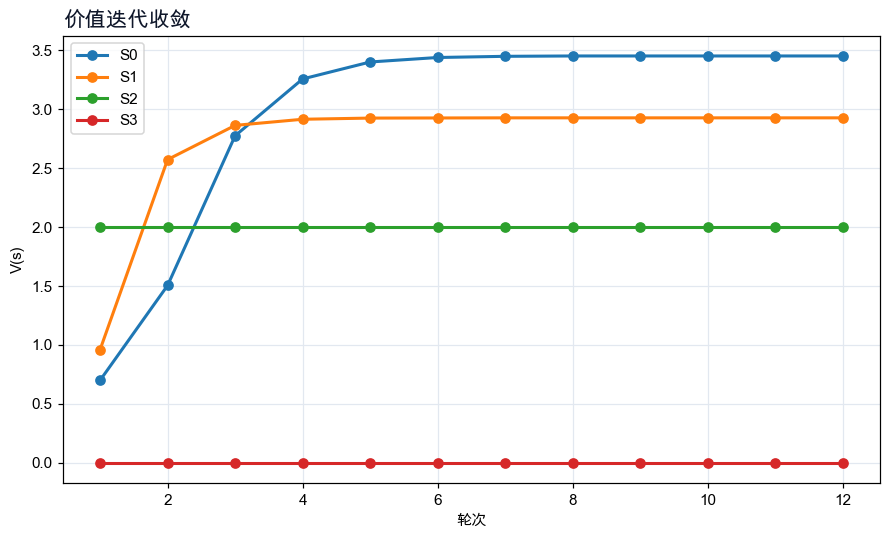

In [4]:
# 绘制各状态价值随迭代收敛。
fig, ax = plt.subplots(figsize=(8.2, 5.0))
for state in states:
    ax.plot(value_trace["轮次"], value_trace[state], marker="o", linewidth=2.0, label=state)
ax.set_title("价值迭代收敛", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_xlabel("轮次")
ax.set_ylabel("V(s)")
ax.grid(True, color="#e2e8f0", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()